In [25]:
import jax 
import jax.numpy as jnp
import numpy as np 
import matplotlib.pyplot as plt 

In [26]:
# parametros 
Swc = 0.1 # saturação da agua conata
Sor = 0.2 # saturação do oleo residual
krw0 = 0.5 # permeabilidade relativa da agua no ponto final
kro0 = 0.9 # permeabilidade relativa do oleo no ponto final
nw = 2.0 # exponte da fase molhante 
no = 3.0 # expoente da fase nao molhante
uw = 1.28 # viscosidade da agua
uo = 0.122 # vicosidade do oleo
phi = (0.15+0.25)/2 #porosidade media
Sw0 = 0.1

v = 0.5 #velocidade definida arbitrariamente



In [27]:
ti = 0.0 
tf = 2.0 
N = 101


Li = 0.0
Lf = 6.0 
M = 101

t = np.linspace(ti,tf,N)
x = np.linspace(Li,Lf,M)

dx = 0.01
maximo = 3.56903545527566
print("De acordo com o Critério CFL dt precisa ser <= {}".format((dx*phi)/(v*maximo)))
dt = 0.001

h = (v*dt)/(dx*phi)

De acordo com o Critério CFL dt precisa ser <= 0.001120750984439591


In [28]:
def Krw(Sw): 
    return krw0 * ((Sw - Swc) /(1 - Swc - Sor))**nw

def Kro(Sw):
    return kro0 * (1 - ((Sw - Swc)/(1 - Swc - Sor)))**no 


def fw(Sw): 
    lmbd_w = Krw(Sw)/uw # mobilidade da agua
    lmbd_o = Kro(Sw)/uo # mobilidade do oleo

    return lmbd_w/(lmbd_w + lmbd_o)


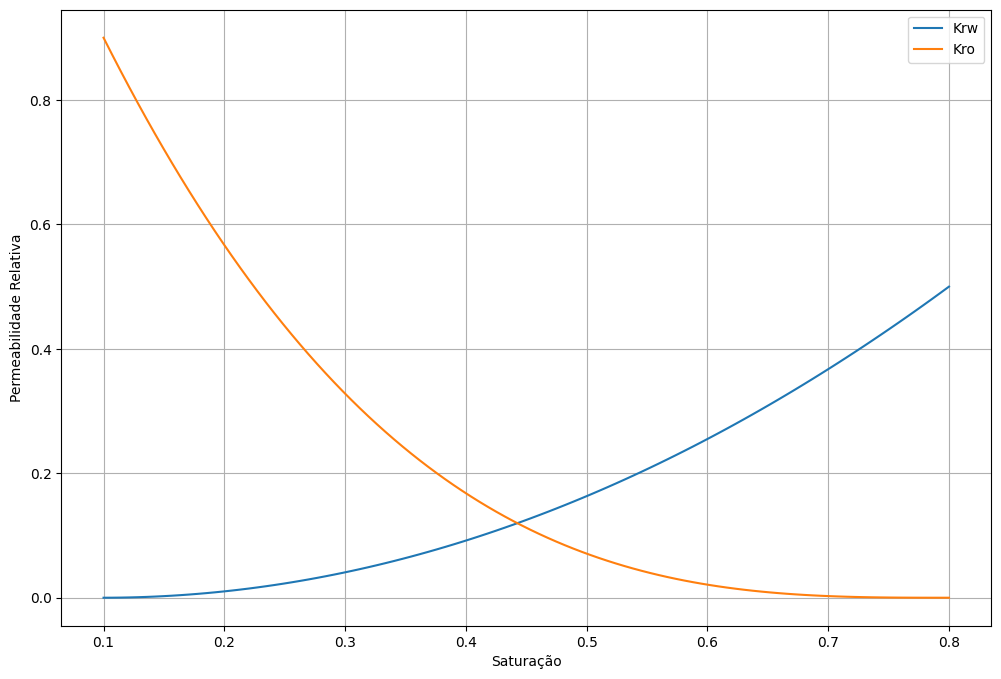

In [29]:
perm_rel_o = np.zeros(M)
perm_rel_w = np.zeros(M)

Sw_plot = np.linspace(Swc, 1-Sor,100)
perm_rel_w = Krw(Sw_plot)
perm_rel_o = Kro(Sw_plot)

plt.figure(figsize=(12,8))
plt.plot(Sw_plot,perm_rel_w, label = 'Krw')
plt.plot(Sw_plot,perm_rel_o,label = 'Kro')
plt.xlabel("Saturação")
plt.ylabel("Permeabilidade Relativa")
plt.grid(True)
plt.legend()
plt.show()

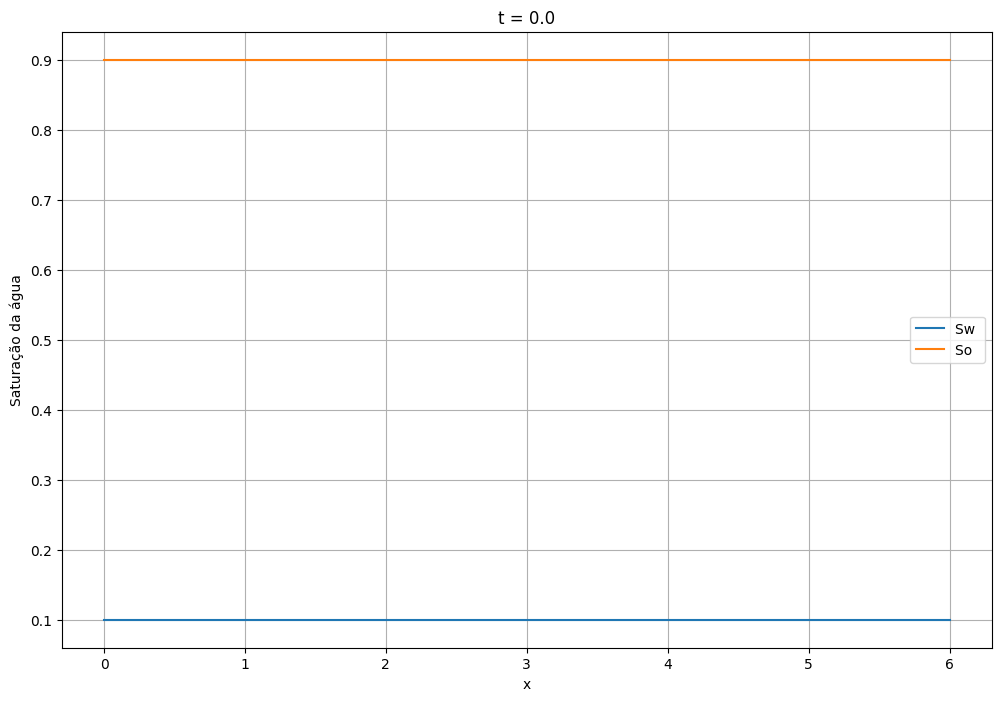

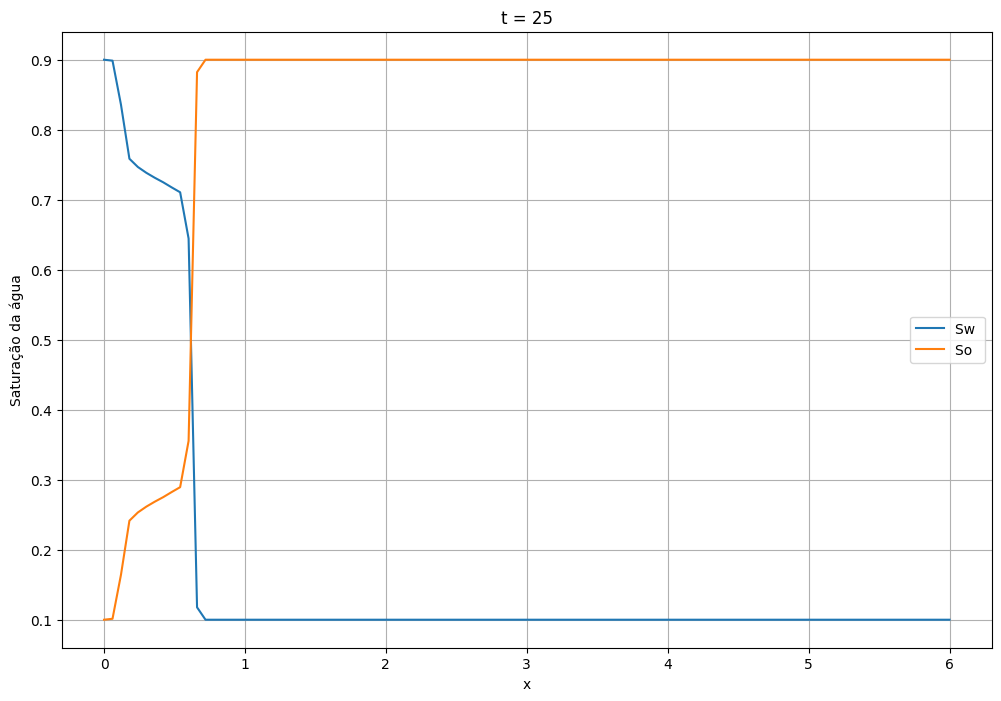

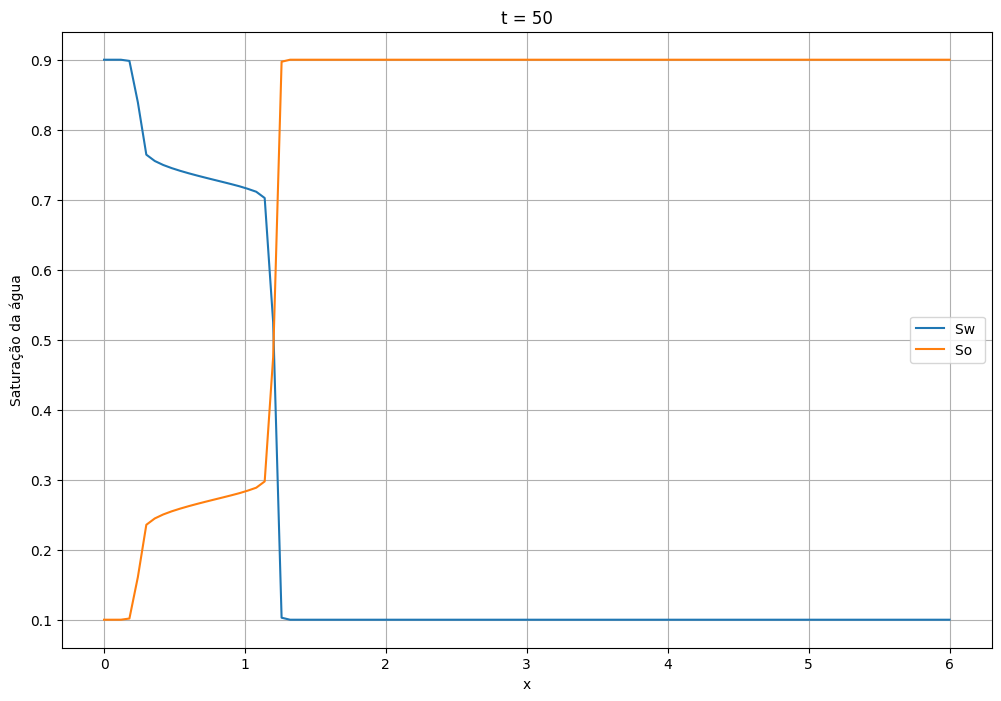

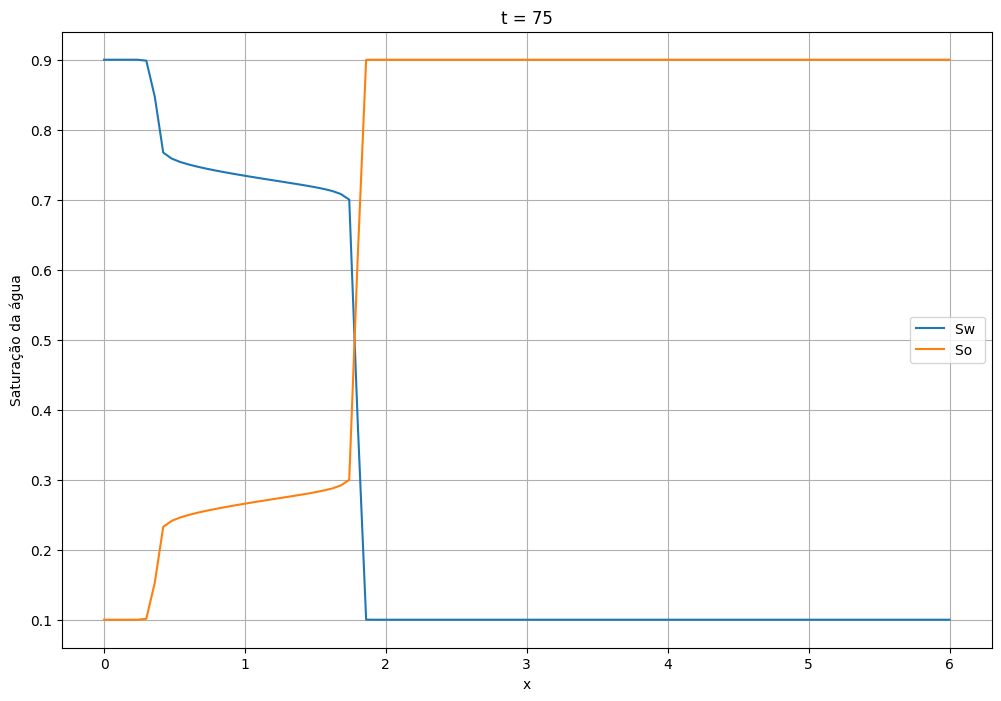

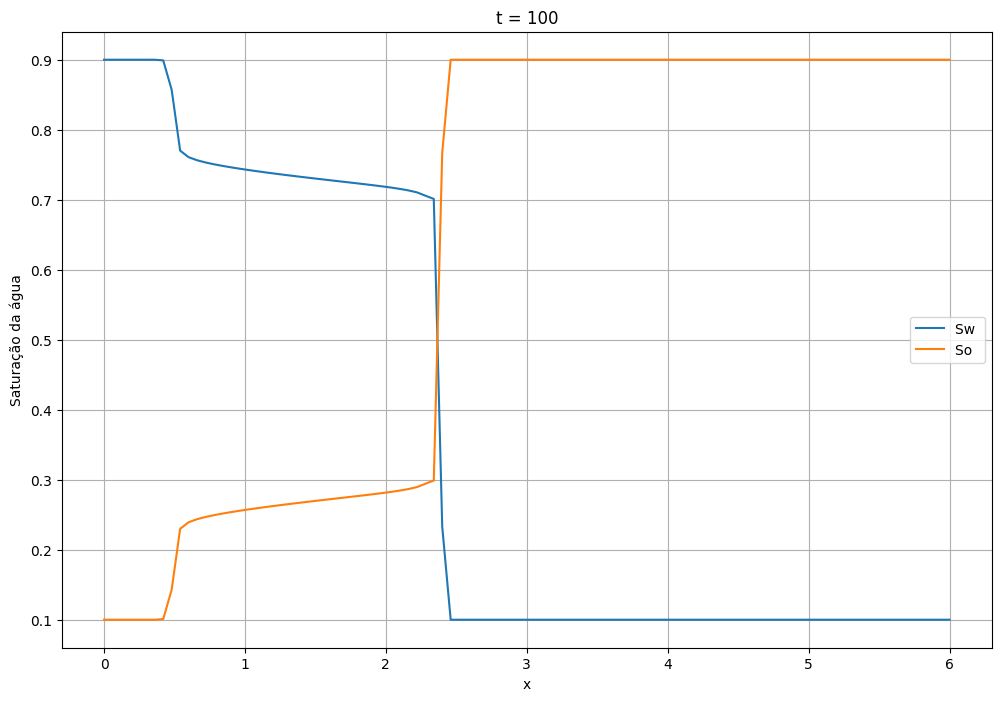

[0.9        0.9        0.9        0.9        0.9        0.89999988
 0.899989   0.89902912 0.8569704  0.77016244 0.76077427 0.75638461
 0.75322683 0.75063702 0.74836718 0.74630353 0.7443858  0.74257804
 0.74085689 0.73920601 0.73761337 0.7360696  0.73456706 0.73309925
 0.73166034 0.73024486 0.72884736 0.72746214 0.72608281 0.72470186
 0.72330983 0.72189412 0.72043707 0.7189117  0.71727657 0.71545507
 0.71331222 0.71054743 0.70578885 0.70117341 0.23291669 0.10000186
 0.1        0.1        0.1        0.1        0.1        0.1
 0.1        0.1        0.1        0.1        0.1        0.1
 0.1        0.1        0.1        0.1        0.1        0.1
 0.1        0.1        0.1        0.1        0.1        0.1
 0.1        0.1        0.1        0.1        0.1        0.1
 0.1        0.1        0.1        0.1        0.1        0.1
 0.1        0.1        0.1        0.1        0.1        0.1
 0.1        0.1        0.1        0.1        0.1        0.1
 0.1        0.1        0.1        0.1        0.1   

In [30]:

Sw = np.zeros(M)
Sw[:] = Sw0



plot_values = [0.0,int(N/4),int(N/2),int(3*N/4),N-1]
Sw_historico = []
Sw_historico.append(Sw.copy()) 

for i in range(N):
    Sw[1:] = Sw[1:] - (h*(fw(Sw[1:])-fw(Sw[:-1])))
    Sw[0] = 1 - Sw0
    if i == 0:
        continue
    elif i in plot_values:
        Sw_historico.append(Sw.copy())


for i in range(len(Sw_historico)):
    
    plt.figure(figsize=(12,8))
    plt.plot(x,Sw_historico[i],label = 'Sw ')
    plt.plot(x,1-Sw_historico[i],label = 'So ')
    plt.xlabel("x")
    plt.ylabel("Saturação da água")
    plt.title("t = {}".format(plot_values[i])) 
    plt.grid(True)
    plt.legend()
    plt.show()

np.set_printoptions(suppress=True)
print(Sw)
